# Import libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
from PIL import Image
import onnxruntime as ort
from transformers import TrOCRProcessor
import numpy as np
import os
import boto3
import botocore

# Load test image

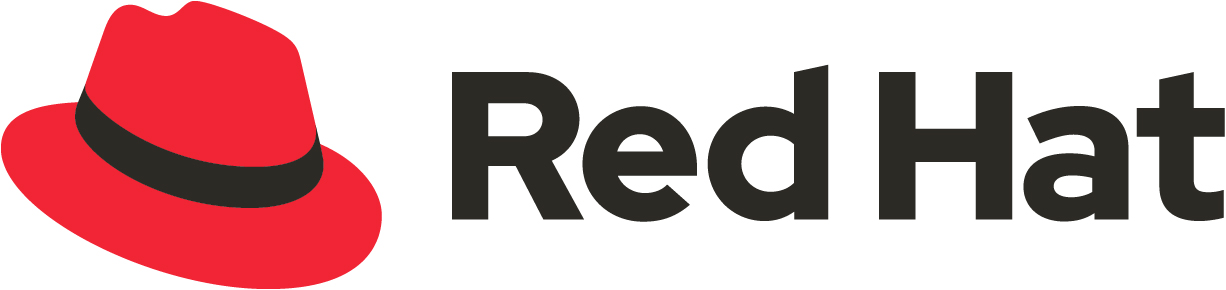

In [3]:
image_path = 'photo.jpg'
image = Image.open(image_path).convert("RGB")
image.show()

# Run model on test image

## Setup S3 bucket

In [4]:
access_key_id = os.environ.get('AWS_ACCESS_KEY_ID')
secret_access_key = os.environ.get('AWS_SECRET_ACCESS_KEY')
endpoint_url = os.environ.get('AWS_S3_ENDPOINT')
region_name = os.environ.get('AWS_DEFAULT_REGION')
bucket_name = os.environ.get('AWS_S3_BUCKET')

In [5]:
session = boto3.session.Session(
    aws_access_key_id = access_key_id,
    aws_secret_access_key = secret_access_key)

s3_resource = session.resource(
    's3',
    config = botocore.client.Config(signature_version='s3v4'),
    endpoint_url = endpoint_url,
    region_name = region_name)

bucket = s3_resource.Bucket(bucket_name)

In [6]:
def list_objects(prefix):
    my_filter = bucket.objects.filter(Prefix=prefix)
    for obj in my_filter.all():
        print(obj.key)

s3_folder = "ocr-demo/"
list_objects(s3_folder)

ocr-demo/config.json
ocr-demo/generation_config.json
ocr-demo/merges.txt
ocr-demo/model.onnx
ocr-demo/preprocessor_config.json
ocr-demo/special_tokens_map.json
ocr-demo/tokenizer.json
ocr-demo/tokenizer_config.json
ocr-demo/vocab.json


## Pre-processing

In [7]:
working_folder = "my_folder/"
os.makedirs(working_folder, exist_ok=True)

In [8]:
s3 = boto3.client(
    's3', 
    endpoint_url = endpoint_url,
    aws_access_key_id = access_key_id, 
    aws_secret_access_key = secret_access_key)

In [9]:
my_filter = bucket.objects.filter(Prefix=s3_folder)

for obj in my_filter.all():
    file_name = obj.key.split("/")[1]
    if file_name != "model.onnx":
        s3.download_file(bucket_name, s3_folder+file_name, working_folder+file_name)

In [10]:
processor = TrOCRProcessor.from_pretrained(working_folder)
pixel_values = processor(images=image, return_tensors="np").pixel_values
batch_size = pixel_values.shape[0]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


## Load model from S3

In [11]:
model_path = working_folder+"model.onnx"
s3.download_file(bucket_name, s3_folder+'model.onnx', model_path)
session = ort.InferenceSession(model_path)

## Define generation parameters

In [12]:
start_token_id = 2
eos_token_id = 2
max_length = 10     # maximum length of the generated sequence

## Processing

In [13]:
# Initialize sequence with start_token_id
generated_sequence = np.full((batch_size, 1), start_token_id, dtype=np.int64)

for step in range(max_length):
    # Run model
    outputs = session.run(None, {
        "pixel_values": pixel_values,
        "decoder_input_ids": generated_sequence
    })

    # Get logits and take argmax to get the next token ID
    next_token_logits = outputs[0][:, -1, :]  # Assuming shape is [batch_size, seq_length, vocab_size]
    next_token_id = np.argmax(next_token_logits, axis=-1).reshape((batch_size, 1))

    # Append next token ID to the sequence
    generated_sequence = np.concatenate([generated_sequence, next_token_id], axis=1)

    # Stop if EOS token is generated
    if np.any(next_token_id == eos_token_id):
        break

## Post-processing

In [14]:
# Convert the token IDs to text
generated_text = processor.batch_decode(generated_sequence, skip_special_tokens=True)[0]

In [15]:
# Display result
print(generated_text)

REDHAT
